In [1]:
import pandas as pd
from sklearn import neighbors
from sklearn.metrics import recall_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
%matplotlib inline
import seaborn as sns


In [2]:
training_data1 = pd.read_csv('dados/dados_modelo1.csv') #semanas 1 a 4(ou 5)
training_data2 = pd.read_csv('dados/dados_modelo2.csv') #semanas 1 a 8
training_data3 = pd.read_csv('dados/dados_modelo3.csv') #semanas 1 a 12

# cuidando dos NaN da coluna TempoQ3
for df in [training_data1, training_data2, training_data3]:
    if 'TempoQ3' in df.columns:
        df['TempoQ3'] = df['TempoQ3'].fillna(df['TempoQ3'].mean())


In [3]:
k = 4

# Função auxiliar para treinar e dividir dados
def treinar_knn(df, test_size=0.3, random_state=42):
    X = df.drop(columns=['Aprovou_Aprovou'])
    y = df['Aprovou_Aprovou']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    clf = neighbors.KNeighborsClassifier(n_neighbors=k, weights='uniform')
    clf.fit(X_train, y_train)
    return clf, X_train, X_test, y_train, y_test

# Modelos
clf1, X1_train, X1_test, y1_train, y1_test = treinar_knn(training_data1)
clf2, X2_train, X2_test, y2_train, y2_test = treinar_knn(training_data2)
clf3, X3_train, X3_test, y3_train, y3_test = treinar_knn(training_data3)


In [4]:
pl = 0

# Predições
y1_pred = clf1.predict(X1_test)
y2_pred = clf2.predict(X2_test)
y3_pred = clf3.predict(X3_test)

# Métricas focando na minoria (pos_label=0)
print("Recall Modelo 1 - semanas 01 a 04:", recall_score(y1_test, y1_pred, pos_label=pl))
print(classification_report(y1_test, y1_pred))

print("Recall Modelo 2 - semanas 01 a 08:", recall_score(y2_test, y2_pred, pos_label=pl))
print(classification_report(y2_test, y2_pred))

print("Recall Modelo 3 - semanas 01 a 12:", recall_score(y3_test, y3_pred, pos_label=pl))
print(classification_report(y3_test, y3_pred))


Recall Modelo 1 - semanas 01 a 04: 0.25
              precision    recall  f1-score   support

         0.0       0.29      0.25      0.27        24
         1.0       0.95      0.96      0.96       389

    accuracy                           0.92       413
   macro avg       0.62      0.61      0.61       413
weighted avg       0.92      0.92      0.92       413

Recall Modelo 2 - semanas 01 a 08: 0.375
              precision    recall  f1-score   support

         0.0       0.33      0.38      0.35        24
         1.0       0.96      0.95      0.96       389

    accuracy                           0.92       413
   macro avg       0.65      0.66      0.66       413
weighted avg       0.92      0.92      0.92       413

Recall Modelo 3 - semanas 01 a 12: 0.5
              precision    recall  f1-score   support

         0.0       0.48      0.50      0.49        24
         1.0       0.97      0.97      0.97       389

    accuracy                           0.94       413
   macro

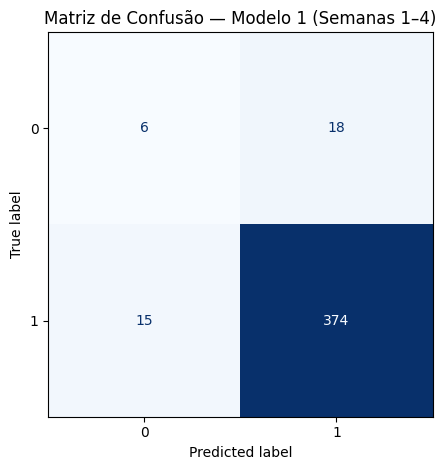

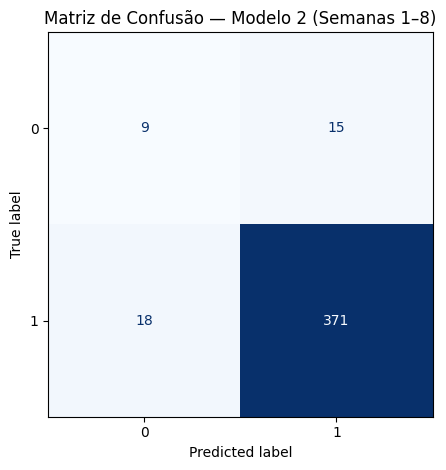

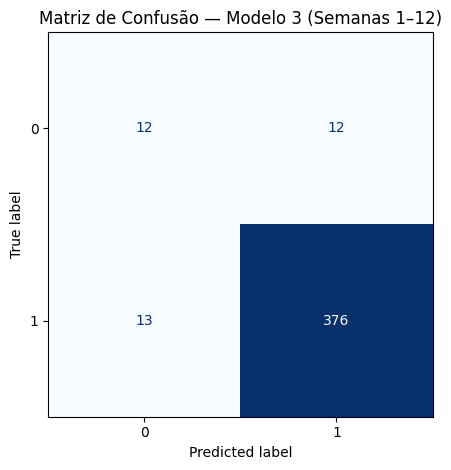

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrizes de confusão para os três modelos (KNN)
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues", values_format="d", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm(y1_test, y1_pred, "Matriz de Confusão — Modelo 1 (Semanas 1–4)")
plot_cm(y2_test, y2_pred, "Matriz de Confusão — Modelo 2 (Semanas 1–8)")
plot_cm(y3_test, y3_pred, "Matriz de Confusão — Modelo 3 (Semanas 1–12)")
